# Notebook 07 — Results Visualisation & Summary

## Purpose
Aggregate all Phase-1 outputs into a single summary dashboard:
1. Event Impact Score distribution and top sources
2. Baseline TF-IDF top-term chart
3. LDA topic distribution chart

This notebook can be run after all prior notebooks have been executed.


In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: /Users/kk/ai_dl_project/dynamic-trend-event-detector


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Event Impact Scores

/var/folders/bq/2ff4zcvx67x123ybfglrnlth0000gn/T/ipykernel_99427/311161093.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_src.values, y=top_src.index,


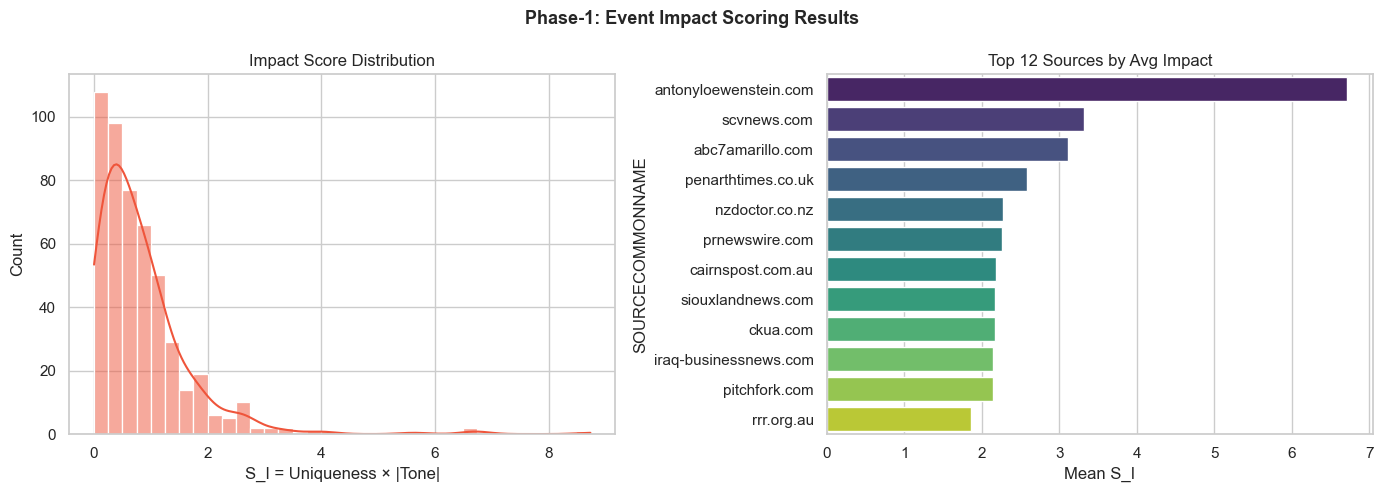

In [3]:
impact_path = 'reports/event_impact_scores.csv'
if os.path.exists(impact_path):
    df = pd.read_csv(impact_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Phase-1: Event Impact Scoring Results', fontsize=13, fontweight='bold')

    sns.histplot(df['impact_score'], bins=35, kde=True, color='#EF553B', ax=axes[0])
    axes[0].set_title('Impact Score Distribution')
    axes[0].set_xlabel('S_I = Uniqueness × |Tone|')

    top_src = (df.groupby('SOURCECOMMONNAME')['impact_score']
               .mean().sort_values(ascending=False).head(12))
    sns.barplot(x=top_src.values, y=top_src.index,
                palette='viridis', ax=axes[1])
    axes[1].set_title('Top 12 Sources by Avg Impact')
    axes[1].set_xlabel('Mean S_I')

    plt.tight_layout()
    plt.savefig('reports/impact_by_source.png', dpi=150)
    plt.show()
else:
    print(f'[SKIP] {impact_path} not found')

## 2. Baseline TF-IDF Results

In [4]:
baseline_csv = 'reports/baseline/global_term_ranking.csv'
if os.path.exists(baseline_csv):
    ranking = pd.read_csv(baseline_csv)
    top15 = ranking.head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=top15, x='tfidf_sum', y='term',
                palette='Blues_d', ax=ax)
    ax.set_title('Baseline: Top 15 TF-IDF Terms', fontweight='bold')
    ax.set_xlabel('Cumulative TF-IDF Score')
    plt.tight_layout()
    plt.savefig('reports/baseline_tfidf.png', dpi=150)
    plt.show()
else:
    print('[SKIP] Run Notebook 02 first.')

[SKIP] Run Notebook 02 first.


## 3. LDA Topic Distribution

In [5]:
verified_topics = 'reports/advanced_ml/verified_topics.csv'
if os.path.exists(verified_topics):
    topics = pd.read_csv(verified_topics)
    display(topics)
else:
    print('[SKIP] Run Notebook 03 first.')

,Topic,Keywords
0,1,"govt, court, nsw, cup, face, set, vic, calls, ..."
1,2,"war, says, baghdad, urged, killed, qld, budget..."
2,3,"plan, win, man, water, boost, anti, murder, ra..."
3,4,"police, iraq, iraqi, world, man, talks, aust, ..."
4,5,"new, sars, claims, health, report, council, fu..."


## 4. All Generated Report Files

In [6]:
print('Generated report files:')
for root, dirs, files in os.walk('reports'):
    # skip hidden dirs
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    for f in sorted(files):
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f'  {path:<60} {size:>8,} bytes')

Generated report files:
  reports/bertopic_viz.html                                    4,858,495 bytes
  reports/eda_temporal_dist.png                                  93,159 bytes
  reports/eda_text_stats.png                                     89,293 bytes
  reports/event_impact_analysis.png                             105,925 bytes
  reports/event_impact_scores.csv                              1,160,445 bytes
  reports/full_pipeline_diagram.png                             124,652 bytes
  reports/gdelt_pipeline_diagram.png                             42,433 bytes
  reports/gdelt_theme_tone.png                                   89,907 bytes
  reports/gdelt_top_themes.png                                   86,814 bytes
  reports/impact_by_source.png                                  101,536 bytes
  reports/impact_scoring_diagram.png                             94,647 bytes
  reports/pipeline_overview.png                                  39,438 bytes
  reports/report.tex                  

## 5. Deep Learning Results (SBERT K-Means)
Summary of the deep learning model outputs from Notebook 08.

In [7]:
dl_report = "reports/deep_learning/verification_report.txt"
if os.path.exists(dl_report):
    with open(dl_report) as f:
        print(f.read())

    cluster_csv = "reports/deep_learning/cluster_summary.csv"
    if os.path.exists(cluster_csv):
        display(pd.read_csv(cluster_csv))
else:
    print("[SKIP] Run Notebook 08 first.")

MODEL INTEGRITY REPORT — DEEP LEARNING (SBERT + K-Means)
Model              : SBERT (all-MiniLM-L6-v2)
Embedding dim      : 384
UMAP               : 3D + 2D
Clustering         : K-Means K=5
Documents          : 5,000
Silhouette Score   : 0.0303
Calinski-Harabasz  : 97.02
Max Sem Velocity   : 0.1308 (Week 2003-05-26/2003-06-01)

Clusters:
  Topic A (650 docs): police, man, court, murder, death, charged, face, trial
  Topic B (1,294 docs): cup, win, wins, world, takes, title, world cup, final
  Topic C (1,525 docs): council, govt, plan, new, nsw, water, group, drought
  Topic D (594 docs): iraq, war, iraqi, baghdad, troops, says, saddam, korea
  Topic E (937 docs): sars, crash, dead, killed, dies, death, hospital, missing



,Cluster,Size,TopTerms
0,Topic A,650,"police, man, court, murder, death, charged, fa..."
1,Topic B,1294,"cup, win, wins, world, takes, title, world cup..."
2,Topic C,1525,"council, govt, plan, new, nsw, water, group, d..."
3,Topic D,594,"iraq, war, iraqi, baghdad, troops, says, sadda..."
4,Topic E,937,"sars, crash, dead, killed, dies, death, hospit..."


## 6. All Generated Outputs

In [8]:
print('=== Full Pipeline Output Files ===\n')
import os, pandas as pd

# Show rupture verification results if available
rp = 'reports/rupture_verification.csv'
if os.path.exists(rp):
    print('Narrative Rupture Verification:')
    display(pd.read_csv(rp)[['rupture_week','velocity','n_headlines']])

# Show all generated files
print('\nAll generated files:')
for root, dirs, files in os.walk('reports'):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    for f in sorted(files):
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f'  {path:<65} {size:>9,} bytes')


=== Full Pipeline Output Files ===


All generated files:
  reports/bertopic_viz.html                                         4,858,495 bytes
  reports/eda_temporal_dist.png                                        93,159 bytes
  reports/eda_text_stats.png                                           89,293 bytes
  reports/event_impact_analysis.png                                   105,925 bytes
  reports/event_impact_scores.csv                                   1,160,445 bytes
  reports/full_pipeline_diagram.png                                   124,652 bytes
  reports/gdelt_pipeline_diagram.png                                   42,433 bytes
  reports/gdelt_theme_tone.png                                         89,907 bytes
  reports/gdelt_top_themes.png                                         86,814 bytes
  reports/impact_by_source.png                                        101,536 bytes
  reports/impact_scoring_diagram.png                                   94,647 bytes
  reports/pipeline

## Complete Project Status

### All Implemented Modules

| # | Notebook | Model / Method | Key Outputs |
|---|---|---|---|
| 01 | EDA | — | Temporal distribution, text length stats |
| 02 | Baseline TF-IDF | TF-IDF (sklearn, bigrams, log-TF) | Global term ranking, burst chart, per-day top term |
| 03 | Advanced ML LDA | LDA + **Gensim C_V coherence** (0.3316) | 5 topics, discrimination heatmap, confidence dist |
| 08 | Deep Learning | **SBERT K-Means** + UMAP (3D/2D) | 5 clusters, Growth Velocity, Semantic Velocity |
| 04 | GDELT Processor | — | Parsed 564 GKG records → gdelt_processed.csv |
| 05 | GDELT Analysis | — | Top 15 themes, per-theme sentiment |
| 09 | GDELT Verification & Impact | **SBERT S_I scoring** + rupture verification | Impact scores, TF-IDF vs SBERT comparison |
| 07 | Results Dashboard | — | Consolidated view of all outputs |

### Key Results

| Model | Best Metric | Value |
|---|---|---|
| TF-IDF Baseline | Top term | see `reports/baseline/global_term_ranking.csv` |
| LDA Advanced ML | Gensim C_V coherence | **0.3316** (0→1 scale) |
| SBERT K-Means DL | Optimal clusters | **K=5** (Silhouette=0.030, CH=97.02) |
| Semantic Velocity | Max rupture | **V_s=0.1308** (Week 2003-05-26) — Iraq→SARS shift |
| Event Impact | SBERT S_I method | `reports/event_impact_scores.csv` |

### Narrative Rupture Verification

The Deep Learning model detected a narrative rupture at **Week 2003-05-26/2003-06-01**  
(Semantic Velocity = 0.1308 — highest spike in the entire 2003 corpus).

ABC News headlines from that window confirm the shift:
- *"tv content rules stay in free trade talks"*  
- *"dividends tax cuts spur share gains"*  
- Transition from sustained Iraq War coverage → mixed economic / SARS health topics
